In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df_flood_risk = pd.read_csv("urban_pluvial_flood_risk_dataset.csv")

# DATA PREPARATION

In [ ]:
df_flood_risk.columns

Index(['segment_id', 'city_name', 'admin_ward', 'latitude', 'longitude',
       'catchment_id', 'elevation_m', 'dem_source', 'land_use', 'soil_group',
       'drainage_density_km_per_km2', 'storm_drain_proximity_m',
       'storm_drain_type', 'rainfall_source',
       'historical_rainfall_intensity_mm_hr', 'return_period_years',
       'risk_labels'],
      dtype='object')

In [ ]:
df_flood_risk.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2963 entries, 0 to 2962
Data columns (total 17 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   segment_id                           2963 non-null   object 
 1   city_name                            2963 non-null   object 
 2   admin_ward                           2963 non-null   object 
 3   latitude                             2963 non-null   float64
 4   longitude                            2963 non-null   float64
 5   catchment_id                         2963 non-null   object 
 6   elevation_m                          2802 non-null   float64
 7   dem_source                           2963 non-null   object 
 8   land_use                             2963 non-null   object 
 9   soil_group                           2601 non-null   object 
 10  drainage_density_km_per_km2          2679 non-null   float64
 11  storm_drain_proximity_m       

In [ ]:
#AAAAA NOOOOO I RE-RUN IT AND CANNOT UNDO THE CLEANED VER.
df_flood_risk.head(20)

,segment_id,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,...,historical_rainfall_intensity_mm_hr,return_period_years,event_date,monitor,ponding_hotspot,low_lying,sparse_drainage,extreme_rain_history,is_risky,elevation_group
0,SEG-00001,Colombo,SriLanka,Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,...,39.4,50,0,1,0,0,0,0,0,High (>=5m)
1,SEG-00002,Chennai,India,Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,...,56.8,25,2025-05-02,0,1,1,0,0,1,Low (<5m)
2,SEG-00003,Ahmedabad,India,Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,...,16.3,5,0,1,0,0,0,0,0,High (>=5m)
3,SEG-00004,HongKong,China,Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,...,77.0,10,0,1,0,0,0,0,0,High (>=5m)
4,SEG-00005,Durban,SouthAfrica,Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,...,20.8,5,0,1,0,0,0,0,0,High (>=5m)
5,SEG-00006,Bangkok,Thailand,Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,...,120.5,50,0,0,0,0,0,1,1,High (>=5m)
6,SEG-00007,Nairobi,Kenya,Ward J,-1.374024,36.730491,CAT-112,15.80,Copernicus_GLO-30_v2023,Residential,...,39.3,10,0,1,0,0,0,0,0,High (>=5m)
7,SEG-00008,Bangkok,Thailand,Zone X,13.746372,100.484051,CAT-116,20.08,SRTM_1arc,Residential,...,74.5,10,0,1,0,0,0,0,0,High (>=5m)
8,SEG-00009,WashingtonDC,USA,Sector 12,38.870843,-76.900953,CAT-095,0.19,Copernicus_GLO-90_v2022,Commercial,...,58.2,10,2024-02-14,0,0,1,0,0,1,Low (<5m)
9,SEG-00010,Vancouver,Canada,Sector 5,49.394900,-123.199393,CAT-066,19.05,SRTM_3arc,Commercial,...,20.1,5,0,1,0,0,0,0,0,High (>=5m)


# DATA CLEANING

In [ ]:
# Check for duplication
df_flood_risk.duplicated().any()

np.False_

In [ ]:
# % of  rows missing in each column

for column in df_flood_risk.columns:
   percentage = df_flood_risk[column].isnull().mean()
   print(column + ': ' + str(round(percentage * 100, 2)))

segment_id: 0.0
city_name: 0.0
admin_ward: 0.0
latitude: 0.0
longitude: 0.0
catchment_id: 0.0
elevation_m: 5.43
dem_source: 0.0
land_use: 0.0
soil_group: 12.22
drainage_density_km_per_km2: 9.58
storm_drain_proximity_m: 8.07
storm_drain_type: 6.01
rainfall_source: 10.63
historical_rainfall_intensity_mm_hr: 0.0
return_period_years: 0.0
risk_labels: 0.0


In [ ]:
df_flood_risk.head(20)

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,NaN,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
5,SEG-00006,"Bangkok, Thailand",Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,C,8.97,30.0,Manhole,LocalGauge,120.5,50,extreme_rain_history
6,SEG-00007,"Nairobi, Kenya",Ward J,-1.374024,36.730491,CAT-112,15.80,Copernicus_GLO-30_v2023,Residential,A,8.25,43.0,Manhole,LocalGauge,39.3,10,monitor
7,SEG-00008,"Bangkok, Thailand",Zone X,13.746372,100.484051,CAT-116,20.08,SRTM_1arc,Residential,C,5.88,31.1,CurbInlet,ERA5,74.5,10,monitor
8,SEG-00009,"Washington DC, USA",Sector 12,38.870843,-76.900953,CAT-095,0.19,Copernicus_GLO-90_v2022,Commercial,NaN,7.79,153.3,NaN,ERA5,58.2,10,low_lying|event_2024-02-14
9,SEG-00010,"Vancouver, Canada",Sector 5,49.394900,-123.199393,CAT-066,19.05,SRTM_3arc,Commercial,D,NaN,49.7,GratedInlet,ERA5,20.1,5,monitor


### List of columns that need to be cleaned and fill missing values:

Using Mode (categorical values):
    'soil_group'
    'storm_drain_type'
    'rainfall_source'

Using Median (numerical values):
    'elevation_m'
    'drainage_density_km_per_km2'
    'storm_drain_proximity_m'
        


In [ ]:
# Fill missing categorical values with mode (permanent)
df_flood_risk['soil_group'] = df_flood_risk['soil_group'].fillna(df_flood_risk['soil_group'].mode()[0])
df_flood_risk['storm_drain_type'] = df_flood_risk['storm_drain_type'].fillna(df_flood_risk['storm_drain_type'].mode()[0])
df_flood_risk['rainfall_source'] = df_flood_risk['rainfall_source'].fillna(df_flood_risk['rainfall_source'].mode()[0])

In [ ]:
df_flood_risk.isnull().sum()

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,B,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,NaN,78.8,GratedInlet,ERA5,46.5,10,monitor
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,NaN,236.1,GratedInlet,ERA5,27.7,2,monitor
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying


In [ ]:
df_flood_risk

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,drainage_density_km_per_km2,storm_drain_proximity_m,storm_drain_type,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,NaN,Copernicus_EEA-10_v5,Institutional,B,4.27,160.5,CurbInlet,ERA5,39.4,50,monitor
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,7.54,NaN,OpenChannel,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,11.00,152.5,OpenChannel,IMD,16.3,5,monitor
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,7.32,37.0,Manhole,ERA5,77.0,10,monitor
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,4.50,292.4,OpenChannel,ERA5,20.8,5,monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,NaN,78.8,GratedInlet,ERA5,46.5,10,monitor
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,5.54,4.9,OpenChannel,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,NaN,236.1,GratedInlet,ERA5,27.7,2,monitor
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,8.74,294.8,OpenChannel,ERA5,131.6,100,extreme_rain_history|low_lying


In [ ]:
# Calculate median of elevation_m
median_elevation = round(df_flood_risk['elevation_m'].median(),2)
median_elevation

np.float64(25.13)

In [ ]:
df_flood_risk['elevation_m'] = df_flood_risk['elevation_m'].fillna(median_elevation)

In [ ]:
median_drainage_density = df_flood_risk['drainage_density_km_per_km2'].median()
median_drainage_density

np.float64(6.25)

In [ ]:
df_flood_risk['drainage_density_km_per_km2'] = df_flood_risk['drainage_density_km_per_km2'].fillna(median_drainage_density)

In [ ]:
median_proximity = round(df_flood_risk['storm_drain_proximity_m'].median(),1)
median_proximity

np.float64(91.7)

In [ ]:
df_flood_risk['storm_drain_proximity_m'] = df_flood_risk['storm_drain_proximity_m'].fillna(median_proximity)

In [ ]:
df_flood_risk.isnull().sum()

segment_id                             0
city_name                              0
admin_ward                             0
latitude                               0
longitude                              0
catchment_id                           0
elevation_m                            0
dem_source                             0
land_use                               0
soil_group                             0
drainage_density_km_per_km2            0
storm_drain_proximity_m                0
storm_drain_type                       0
rainfall_source                        0
historical_rainfall_intensity_mm_hr    0
return_period_years                    0
risk_labels                            0
dtype: int64

In [ ]:
for col in df_flood_risk.columns:
    unique_vals = df_flood_risk[col].dropna().unique()
    print(f"\nColumn: {col}")
    print(f"Unique values ({len(unique_vals)}): {unique_vals}")


Column: segment_id
Unique values (2963): ['SEG-00001' 'SEG-00002' 'SEG-00003' ... 'SEG-02961' 'SEG-02962'
 'SEG-02963']

Column: city_name
Unique values (63): ['Colombo, Sri Lanka' 'Chennai, India' 'Ahmedabad, India'
 'Hong Kong, China' 'Durban, South Africa' 'Bangkok, Thailand'
 'Nairobi, Kenya' 'Washington DC, USA' 'Vancouver, Canada' 'Delhi, India'
 'Athens, Greece' 'Sydney, Australia' 'Miami, USA' 'Lima, Peru'
 'Kuala Lumpur, Malaysia' 'Singapore, Singapore' 'Rome, Italy'
 'Brisbane, Australia' 'Montreal, Canada' 'Hanoi, Vietnam'
 'Seoul, South Korea' 'San Francisco, USA' 'Rotterdam, Netherlands'
 'Bengaluru, India' 'New Orleans, USA' 'Dhaka, Bangladesh' 'Pune, India'
 'Shanghai, China' 'Karachi, Pakistan' 'Amsterdam, Netherlands'
 'Bogotá, Colombia' 'Paris, France' 'Shenzhen, China'
 'Mexico City, Mexico' 'Tehran, Iran' 'Taipei, Taiwan'
 'Jakarta, Indonesia' 'Barcelona, Spain' 'Manila, Philippines'
 'Lagos, Nigeria' 'Accra, Ghana' 'Auckland, New Zealand' 'Tokyo, Japan'
 'Buenos A

In [ ]:
# Safety first
df_flood_risk_backup = df_flood_risk.copy()


In [ ]:
import re #regex: to perform string operations

# --- Extract event_date (YYYY-MM-DD) ---
df_flood_risk['event_date'] = df_flood_risk['risk_labels'].str.extract(r'(\d{4}-\d{2}-\d{2})')

# --- Remove event_YYYY-MM-DD from labels ---
df_flood_risk['risk_labels_clean'] = df_flood_risk['risk_labels'].apply(
    lambda x: re.sub(r'event_\d{4}-\d{2}-\d{2}', '', x)
)

# --- Normalize labels ---
df_flood_risk['risk_labels_clean'] = (
    df_flood_risk['risk_labels_clean']
    .str.strip('|')                            # remove leading/trailing |
    .str.replace(r'\|+', '|', regex=True)      # collapse multiple pipes
    .str.lower()                               # make all lowercase
    .str.strip()                               # remove spaces around
)

# --- One-hot encode ---
risk_dummies = df_flood_risk['risk_labels_clean'].str.get_dummies(sep='|')

# --- Remove duplicate columns safely ---
risk_dummies = risk_dummies.T.groupby(level=0).max().T

# --- Merge back ---
df_flood_risk = pd.concat([df_flood_risk.drop(columns=['risk_labels_clean']), risk_dummies], axis=1)

df_flood_risk

,segment_id,city_name,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,soil_group,...,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,risk_labels,event_date,extreme_rain_history,low_lying,monitor,ponding_hotspot,sparse_drainage
0,SEG-00001,"Colombo, Sri Lanka",Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,B,...,ERA5,39.4,50,monitor,NaN,0,0,1,0,0
1,SEG-00002,"Chennai, India",Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,D,...,ERA5,56.8,25,ponding_hotspot|low_lying|event_2025-05-02,2025-05-02,0,1,0,1,0
2,SEG-00003,"Ahmedabad, India",Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,B,...,IMD,16.3,5,monitor,NaN,0,0,1,0,0
3,SEG-00004,"Hong Kong, China",Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,B,...,ERA5,77.0,10,monitor,NaN,0,0,1,0,0
4,SEG-00005,"Durban, South Africa",Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,C,...,ERA5,20.8,5,monitor,NaN,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,"Paris, France",Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,C,...,ERA5,46.5,10,monitor,NaN,0,0,1,0,0
2959,SEG-02960,"Shanghai, China",Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,C,...,LocalGauge,70.6,5,ponding_hotspot|low_lying|event_2024-07-26,2024-07-26,0,1,0,1,0
2960,SEG-02961,"Vancouver, Canada",Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,B,...,ERA5,27.7,2,monitor,NaN,0,0,1,0,0
2961,SEG-02962,"Lagos, Nigeria",Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,B,...,ERA5,131.6,100,extreme_rain_history|low_lying,NaN,1,1,0,0,0


In [ ]:
#Drop original risk_labels column
df_flood_risk = df_flood_risk.drop(columns=['risk_labels'])

In [ ]:
# Replace all NaN values in the 'event_date' column with the integer 0
df_flood_risk['event_date'] = df_flood_risk['event_date'].fillna(0)

### Split city_name

In [ ]:
# Step 1: Split the 'city_name' column by the comma and a space
df_flood_risk[['city', 'country']] = df_flood_risk['city_name'].str.split(', ', expand=True)

# Step 2: Remove all spaces from the new 'city' and 'country' columns
df_flood_risk['city'] = df_flood_risk['city'].str.replace(' ', '', regex=True)
df_flood_risk['country'] = df_flood_risk['country'].str.replace(' ', '', regex=True)


In [ ]:
# DROP COLUUMNNN

df_flood_risk = df_flood_risk.drop(columns = ['city_name'])

In [ ]:
# Define risk labels (excluding 'monitor')
risk_labels_filtered = ['ponding_hotspot', 'low_lying', 'sparse_drainage', 'extreme_rain_history']

# Add 'is_risky' column permanently
df_flood_risk['is_risky'] = (df_flood_risk[risk_labels_filtered].sum(axis=1) > 0).astype(int)

In [ ]:
df_flood_risk.columns

Index(['segment_id', 'admin_ward', 'latitude', 'longitude', 'catchment_id',
       'elevation_m', 'dem_source', 'land_use', 'soil_group',
       'drainage_density_km_per_km2', 'storm_drain_proximity_m',
       'storm_drain_type', 'rainfall_source',
       'historical_rainfall_intensity_mm_hr', 'return_period_years',
       'event_date', 'extreme_rain_history', 'low_lying', 'monitor',
       'ponding_hotspot', 'sparse_drainage', 'city', 'country', 'is_risky'],
      dtype='object')

In [ ]:
lis=['segment_id', 'city', 'country', 'admin_ward', 'latitude', 'longitude', 'catchment_id', 'elevation_m', 'dem_source', 'land_use', 'soil_group',
    'drainage_density_km_per_km2', 'storm_drain_proximity_m', 'storm_drain_type', 'rainfall_source', 'historical_rainfall_intensity_mm_hr', 'return_period_years',
     'event_date', 'monitor', 'ponding_hotspot', 'low_lying','sparse_drainage', 'extreme_rain_history', 'is_risky' ]
df_flood_risk = df_flood_risk[lis]
df_flood_risk

,segment_id,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,...,rainfall_source,historical_rainfall_intensity_mm_hr,return_period_years,event_date,monitor,ponding_hotspot,low_lying,sparse_drainage,extreme_rain_history,is_risky
0,SEG-00001,Colombo,SriLanka,Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,...,ERA5,39.4,50,0,1,0,0,0,0,0
1,SEG-00002,Chennai,India,Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,...,ERA5,56.8,25,2025-05-02,0,1,1,0,0,1
2,SEG-00003,Ahmedabad,India,Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,...,IMD,16.3,5,0,1,0,0,0,0,0
3,SEG-00004,HongKong,China,Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,...,ERA5,77.0,10,0,1,0,0,0,0,0
4,SEG-00005,Durban,SouthAfrica,Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,...,ERA5,20.8,5,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2958,SEG-02959,Paris,France,Ward B,48.872870,2.246250,CAT-036,30.46,Copernicus_GLO-30_v2023,Residential,...,ERA5,46.5,10,0,1,0,0,0,0,0
2959,SEG-02960,Shanghai,China,Sector 17,31.195529,121.435540,CAT-050,-3.00,SRTM_3arc,Industrial,...,LocalGauge,70.6,5,2024-07-26,0,1,1,0,0,1
2960,SEG-02961,Vancouver,Canada,Sector 12,49.162783,-123.037084,CAT-052,14.16,Copernicus_GLO-90_v2022,Green,...,ERA5,27.7,2,0,1,0,0,0,0,0
2961,SEG-02962,Lagos,Nigeria,Zone V,6.504570,3.388571,CAT-092,7.00,Copernicus_GLO-30_v2023,Industrial,...,ERA5,131.6,100,0,0,0,1,0,1,1


In [ ]:
df_flood_risk.to_csv('cleaned_flood_risk.csv', index=False)


In [ ]:
df_flood_risk.head(10)

,segment_id,city,country,admin_ward,latitude,longitude,catchment_id,elevation_m,dem_source,land_use,...,historical_rainfall_intensity_mm_hr,return_period_years,event_date,monitor,ponding_hotspot,low_lying,sparse_drainage,extreme_rain_history,is_risky,elevation_group
0,SEG-00001,Colombo,SriLanka,Borough East,6.920633,79.912600,CAT-136,25.13,Copernicus_EEA-10_v5,Institutional,...,39.4,50,0,1,0,0,0,0,0,High (>=5m)
1,SEG-00002,Chennai,India,Ward D,13.076487,80.281774,CAT-049,-2.19,Copernicus_EEA-10_v5,Residential,...,56.8,25,2025-05-02,0,1,1,0,0,1,Low (<5m)
2,SEG-00003,Ahmedabad,India,Sector 12,23.019473,72.638578,CAT-023,30.88,SRTM_3arc,Industrial,...,16.3,5,0,1,0,0,0,0,0,High (>=5m)
3,SEG-00004,HongKong,China,Sector 14,22.302602,114.078673,CAT-168,24.28,SRTM_3arc,Residential,...,77.0,10,0,1,0,0,0,0,0,High (>=5m)
4,SEG-00005,Durban,SouthAfrica,Sector 5,-29.887602,30.911008,CAT-171,35.70,SRTM_3arc,Industrial,...,20.8,5,0,1,0,0,0,0,0,High (>=5m)
5,SEG-00006,Bangkok,Thailand,Borough Harbor,13.730254,100.441634,CAT-132,15.36,Copernicus_GLO-30_v2023,Roads,...,120.5,50,0,0,0,0,0,1,1,High (>=5m)
6,SEG-00007,Nairobi,Kenya,Ward J,-1.374024,36.730491,CAT-112,15.80,Copernicus_GLO-30_v2023,Residential,...,39.3,10,0,1,0,0,0,0,0,High (>=5m)
7,SEG-00008,Bangkok,Thailand,Zone X,13.746372,100.484051,CAT-116,20.08,SRTM_1arc,Residential,...,74.5,10,0,1,0,0,0,0,0,High (>=5m)
8,SEG-00009,WashingtonDC,USA,Sector 12,38.870843,-76.900953,CAT-095,0.19,Copernicus_GLO-90_v2022,Commercial,...,58.2,10,2024-02-14,0,0,1,0,0,1,Low (<5m)
9,SEG-00010,Vancouver,Canada,Sector 5,49.394900,-123.199393,CAT-066,19.05,SRTM_3arc,Commercial,...,20.1,5,0,1,0,0,0,0,0,High (>=5m)


# DATA ANALYSIS

In [ ]:
print(len(df_flood_risk))       # total rows
# or
print(df_flood_risk.shape[0])   # total rows
print(df_flood_risk.shape[1])   # total columns

2963
2963
24


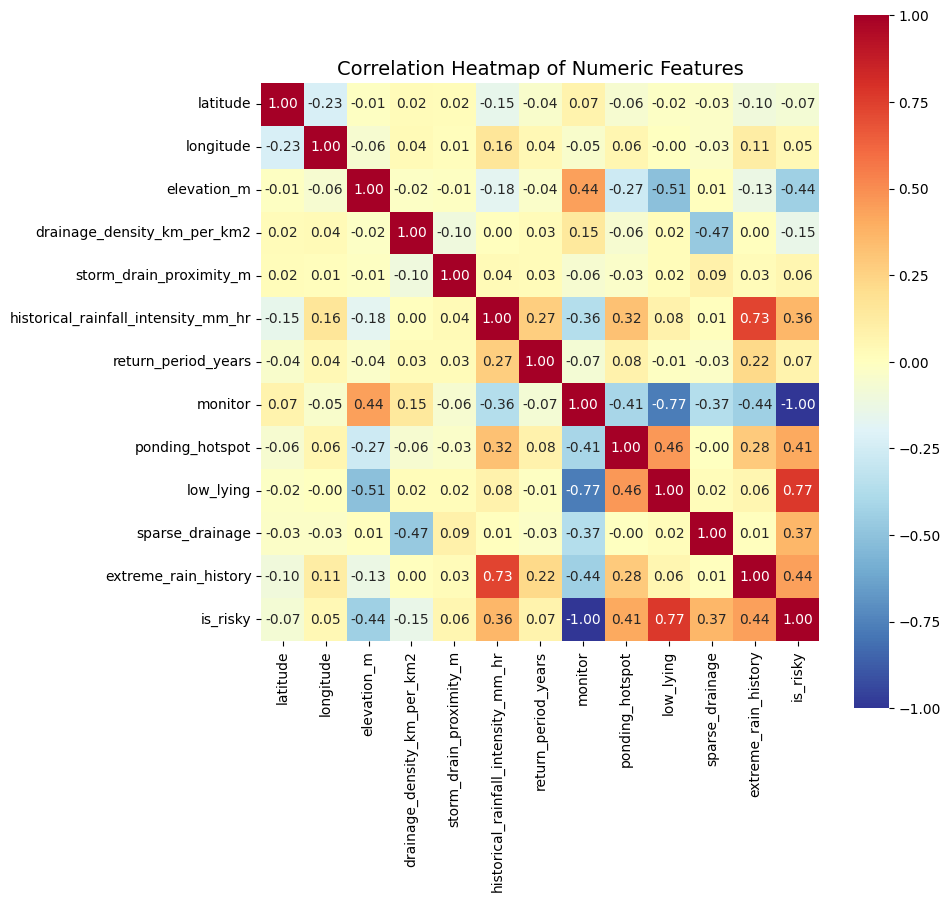

In [ ]:
# 1. Correlation Heatmap
plt.figure(figsize=(9,9))

# Select only numeric columns
numeric_df = df_flood_risk.select_dtypes(include=['float64', 'int64'])

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    cbar=True,
    square=True
)

plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()


Average Rainfall Intensity (mm/hr):
 is_risky
0    37.450100
1    56.901754
Name: historical_rainfall_intensity_mm_hr, dtype: float64


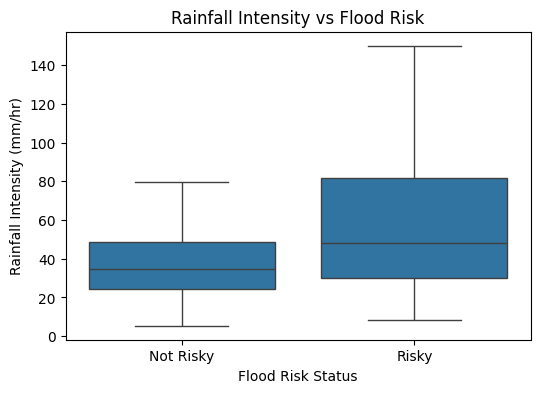

In [ ]:
# Compare average rainfall intensity for risky vs non-risky areas
avg_rainfall = df_flood_risk.groupby("is_risky")["historical_rainfall_intensity_mm_hr"].mean()
print("Average Rainfall Intensity (mm/hr):\n", avg_rainfall)

# Boxplot to visualize distribution
plt.figure(figsize=(6,4))
sns.boxplot(x="is_risky", y="historical_rainfall_intensity_mm_hr", data=df_flood_risk)
plt.xticks([0,1], ["Not Risky", "Risky"])
plt.xlabel("Flood Risk Status")
plt.ylabel("Rainfall Intensity (mm/hr)")
plt.title("Rainfall Intensity vs Flood Risk")
plt.show()


Average distance to drains:
is_risky
0    116.620863
1    128.975335
Name: storm_drain_proximity_m, dtype: float64

Areas farther from drains are more likely to be risky.


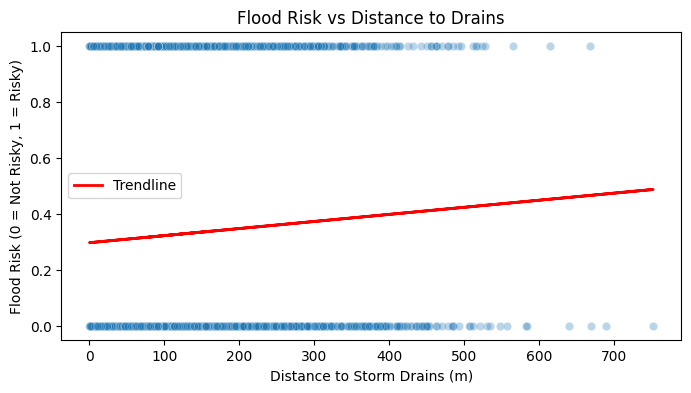

In [ ]:
avg_distances = df_flood_risk.groupby("is_risky")["storm_drain_proximity_m"].mean()
print("Average distance to drains:")
print(avg_distances)

if avg_distances[1] > avg_distances[0]:
    print("\nAreas farther from drains are more likely to be risky.")
else:
    print("\nProximity to drains does not show clear risk difference.")

# Scatterplot + trendline
plt.figure(figsize=(8,4))
sns.scatterplot(x="storm_drain_proximity_m", y="is_risky", data=df_flood_risk, alpha=0.3)

# Fit a simple linear regression using numpy (polyfit degree 1)
x = df_flood_risk["storm_drain_proximity_m"].values
y = df_flood_risk["is_risky"].values
m, b = np.polyfit(x, y, 1)

# Plot regression line
plt.plot(x, m*x + b, color="red", linewidth=2, label="Trendline")
plt.title("Flood Risk vs Distance to Drains")
plt.xlabel("Distance to Storm Drains (m)")
plt.ylabel("Flood Risk (0 = Not Risky, 1 = Risky)")
plt.legend()
plt.show()


waiiiit ad-on i might forgot ueue

ponding_hotspot
count_0    2741
count_1     222
Name: count, dtype: int64


low_lying
count_0    2297
count_1     666
Name: count, dtype: int64


sparse_drainage
count_0    2782
count_1     181
Name: count, dtype: int64


extreme_rain_history
count_0    2709
count_1     254
Name: count, dtype: int64




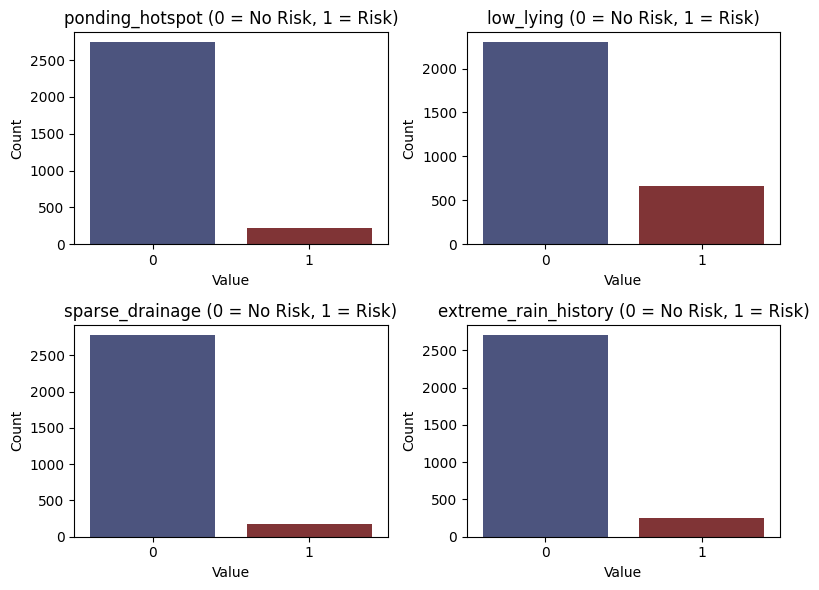

In [ ]:
labels_to_check = ['ponding_hotspot',
                   'low_lying',
                   'sparse_drainage',
                   'extreme_rain_history']

for col in labels_to_check:
    print(df_flood_risk[col].value_counts().rename({0: "count_0", 1: "count_1"}))
    print("\n")

plt.figure(figsize=(8,6))

for i, col in enumerate(labels_to_check, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=df_flood_risk[col], hue=df_flood_risk[col], palette=["#444e86", "#8d272a"], legend=False)
    plt.title(f"{col} (0 = No Risk, 1 = Risk)")
    plt.xlabel("Value")
    plt.ylabel("Count")

plt.tight_layout()
plt.show()


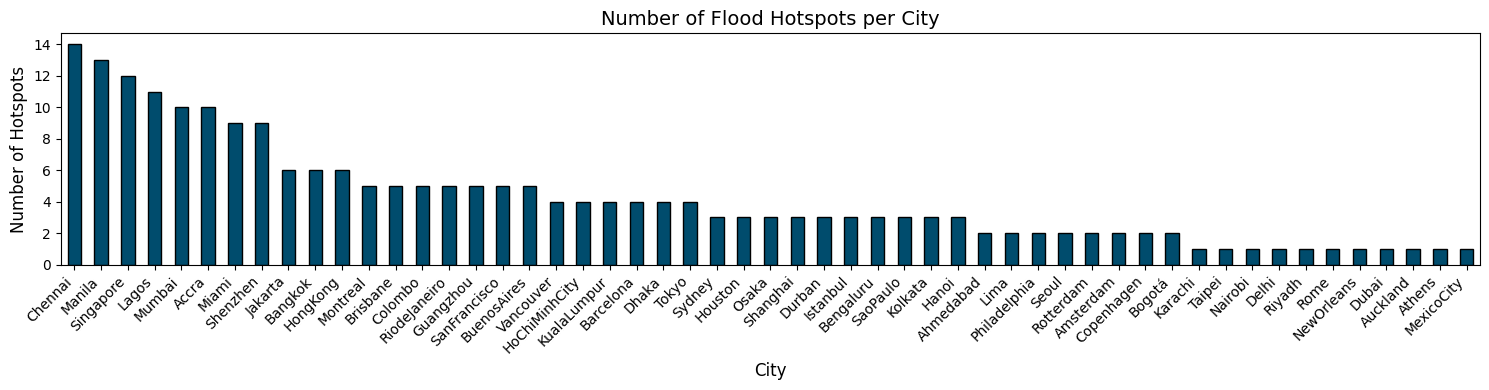

City with highest flood hotspots: Chennai (14 hotspots)


In [ ]:
# Analysis based on location horaaay MANILA LOL
city_hotspot = df_flood_risk[df_flood_risk['ponding_hotspot'] == 1]['city'].value_counts()

top_city = city_hotspot.idxmax()
top_count = city_hotspot.max()

# VIZ

plt.figure(figsize=(15,4))
city_hotspot.plot(kind = 'bar', color = '#004c6d', edgecolor='black')
plt.title("Number of Flood Hotspots per City", fontsize=14)
plt.xlabel("City", fontsize=12)
plt.ylabel("Number of Hotspots", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

top_city, top_count
print(f"City with highest flood hotspots: {top_city} ({top_count} hotspots)")

Average Rainfall Intensity (mm/hr):
 is_risky
0    37.450100
1    56.901754
Name: historical_rainfall_intensity_mm_hr, dtype: float64


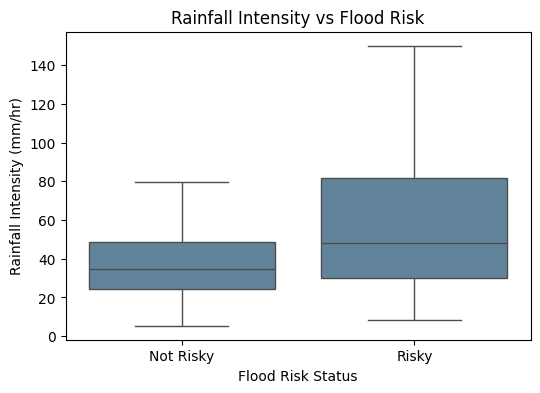

In [ ]:
# Compare average rainfall intensity for risky vs non-risky areas
avg_rainfall = df_flood_risk.groupby("is_risky")["historical_rainfall_intensity_mm_hr"].mean()
print("Average Rainfall Intensity (mm/hr):\n", avg_rainfall)

# Boxplot to visualize distribution
plt.figure(figsize=(6,4))
sns.boxplot(x="is_risky", y="historical_rainfall_intensity_mm_hr", color = '#5886a5', data=df_flood_risk)
plt.xticks([0,1], ["Not Risky", "Risky"])
plt.xlabel("Flood Risk Status")
plt.ylabel("Rainfall Intensity (mm/hr)")
plt.title("Rainfall Intensity vs Flood Risk")
plt.show()


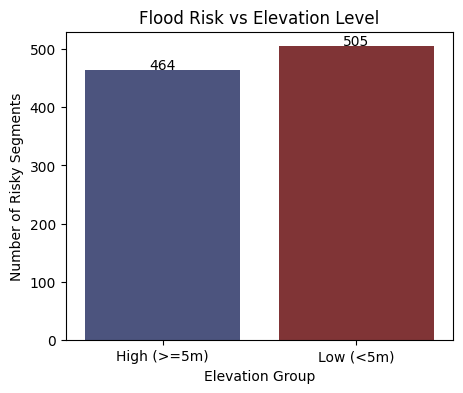

,elevation_group,is_risky
0,High (>=5m),464
1,Low (<5m),505


In [ ]:
# Define low vs high elevation
df_flood_risk['elevation_group'] = df_flood_risk['elevation_m'].apply(lambda x: 'Low (<5m)' if x < 5 else 'High (>=5m)')

# Compare risk counts by elevation group
risk_counts = df_flood_risk.groupby('elevation_group')['is_risky'].sum().reset_index()

# Visualization
plt.figure(figsize=(5,4))
sns.barplot(data=risk_counts, x='elevation_group', y='is_risky',hue="elevation_group", palette=["#444e86", "#8d272a"])
plt.title("Flood Risk vs Elevation Level")
plt.xlabel("Elevation Group")
plt.ylabel("Number of Risky Segments")

# Add values on bars
for index, row in risk_counts.iterrows():
    plt.text(index, row['is_risky']+1, int(row['is_risky']), ha='center')

plt.show()

risk_counts


Soil group distribution in risky areas:
 soil_group
B    380
C    213
D    199
A    177
Name: count, dtype: int64

Most common soil type: B


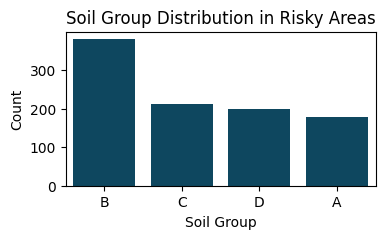

In [ ]:
# Filter only risky areas
risky_areas = df_flood_risk[df_flood_risk['is_risky'] == 1]

# Count soil type distribution
soil_counts = risky_areas['soil_group'].value_counts()

print("Soil group distribution in risky areas:\n", soil_counts)
print("\nMost common soil type:", soil_counts.idxmax())

# Visualize soil type distribution
plt.figure(figsize=(4,2))
sns.countplot(data=risky_areas, x='soil_group', color = '#004c6d', order=soil_counts.index)
plt.title('Soil Group Distribution in Risky Areas')
plt.xlabel('Soil Group')
plt.ylabel('Count')
plt.show()


In [ ]:
df_flood_risk['is_risky'] = df_flood_risk[['ponding_hotspot', 'low_lying', 'sparse_drainage', 'extreme_rain_history']].sum(axis=1)
df_flood_risk['is_risky'] = (df_flood_risk['is_risky'] > 0).astype(int)

# Low elevation < 5
low_elev = df_flood_risk['elevation_m'] < 5
# High rainfall threshold, e.g., >50 mm/hr
high_rain = df_flood_risk['historical_rainfall_intensity_mm_hr'] > 50
# Already risky
already_risky = df_flood_risk['is_risky'] == 1

# Combine criteria
high_risk = df_flood_risk[low_elev & high_rain & already_risky]

# List of highest risk areas
highest_risk_areas = high_risk[['city', 'elevation_m', 'latitude', 'longitude', 'historical_rainfall_intensity_mm_hr']]
highest_risk_areas = highest_risk_areas.sort_values(by=['historical_rainfall_intensity_mm_hr','elevation_m']).to_string(index=False)

print("Highest Risk Areas:")
print(highest_risk_areas)

high_risk_geo = high_risk[['city', 'latitude', 'longitude',
                           'elevation_m', 'historical_rainfall_intensity_mm_hr']]




Highest Risk Areas:
         city  elevation_m   latitude   longitude  historical_rainfall_intensity_mm_hr
       Manila        -3.00  14.577747  120.971288                                 50.2
 SanFrancisco        -3.00  37.695517 -122.400306                                 50.3
      Colombo         1.70   6.876262   79.865923                                 50.3
     Brisbane        -3.00 -27.576618  152.984225                                 50.4
    Amsterdam        -3.00  52.306470    4.899011                                 51.0
 WashingtonDC        -3.00  38.849125  -77.025252                                 51.2
       Manila         0.04  14.518679  121.009838                                 51.7
       Athens        -3.00  37.772098   23.641188                                 51.9
       Sydney         1.95 -33.793664  151.092246                                 51.9
 RiodeJaneiro        -3.00 -22.994480  -43.289465                                 52.0
HoChiMinhCity         1

In [ ]:

# Safety first
df_flood_risk_backup = df_flood_risk.copy()


Text(0.5, 1.0, 'Flood Risk Assessment')

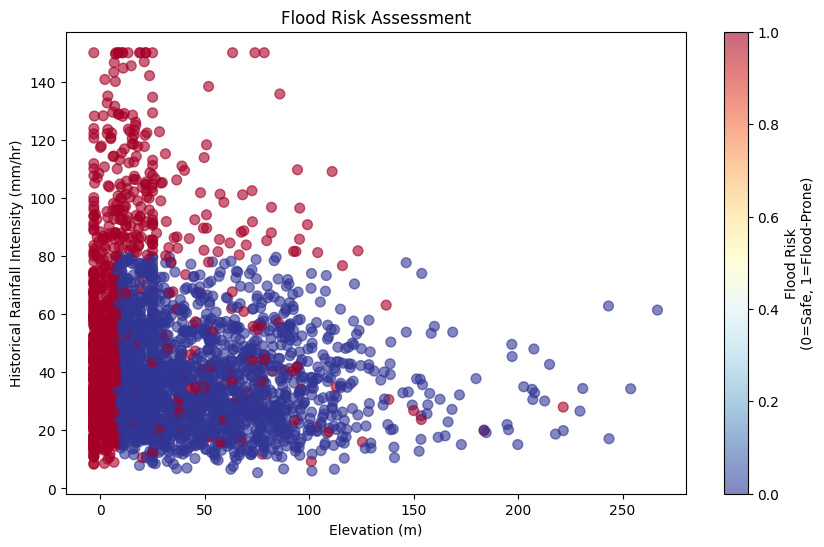

In [ ]:
plt.figure(figsize=(10,6))
scatter = plt.scatter(df_flood_risk['elevation_m'],
                      df_flood_risk['historical_rainfall_intensity_mm_hr'],
                      c=df_flood_risk['is_risky'],
                      alpha=0.6,
                      cmap='RdYlBu_r',  # Different colormap
                      s=50)
plt.colorbar(scatter, label='Flood Risk\n(0=Safe, 1=Flood-Prone)')

# Add missing labels and title
plt.xlabel('Elevation (m)')
plt.ylabel('Historical Rainfall Intensity (mm/hr)')
plt.title('Flood Risk Assessment')